In [1]:
import sys
import os

In [2]:
os.chdir('..')

In [3]:
import config
import train
from coronal_diffusion import models, dataset
from coronal_diffusion.constants import device
from torch.utils.data import DataLoader


/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dedasilv/micromamba/envs/coronal-diffusion/lib/python3.11/site-packages/ai/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
train_dataset = dataset.CoronalFieldDatasetHDF(config.train_dataset_path, augment=False)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
)
scalers_dict = train.get_scalers(config)
model = models.DiffusionModel().to(device)
coeffs, _ = next(iter(train_dataloader))
coeffs = coeffs.to(device)
img_true = train.get_potential_images(model, coeffs, config.radii, scalers_dict)

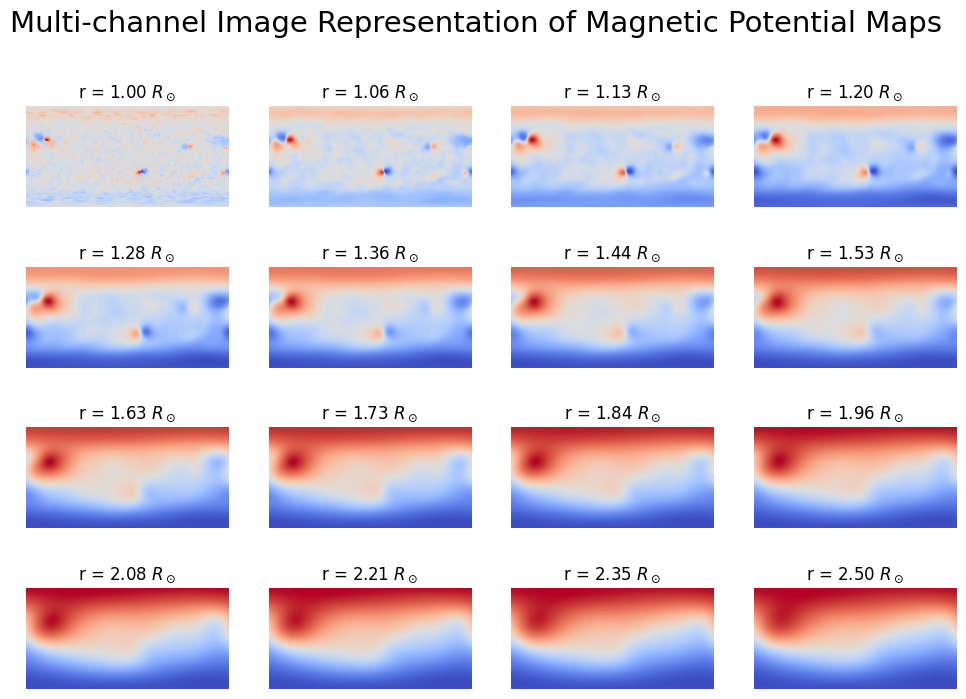

In [7]:
import pylab as plt

img = img_true[0]

fig, axes = plt.subplots(4, 4, sharex=True, sharey=True, figsize=(12, 8))

for i in range(img.shape[0]):
    axes.flatten()[i].imshow(img[i].cpu().numpy(), origin='upper', cmap='coolwarm_r')
    axes.flatten()[i].axis('off')
    axes.flatten()[i].set_title(f'r = {config.radii[i]:.2f} $R_\\odot$')

fig.suptitle('Multi-channel Image Representation of Magnetic Potential Maps', fontsize=21)

!mkdir -p plots/paper
fig.savefig('plots/paper/multichannel_example.png', dpi=300)